# Logistic Regression Classification Workflow

This notebook demonstrates the complete workflow for building a classification model using **Logistic Regression**. We will start with a simple single-variable example to build intuition and then progress to a robust, multi-variable pipeline with comprehensive evaluation.

1. **Single-variable classification**: Build intuition with visual sigmoid curves
2. **Complete ML workflow**: Load → Split → Scale → Train → Evaluate → Analyze
3. **Evaluation metrics**: Accuracy, precision, recall, F1-score, confusion matrix
4. **Best practices**: Preventing data leakage, stratification, proper scaling

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix, 
    classification_report,
    ConfusionMatrixDisplay
)

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# Load data
iris = load_iris()
X_all = iris.data
y_all = iris.target

print(f"Dataset loaded: {X_all.shape[0]} samples, {X_all.shape[1]} features")

Dataset loaded: 150 samples, 4 features


## Part 1: Building Intuition with Single Variable Classification

To understand how Logistic Regression works, let's simplify the problem. We will try to classify whether a flower is **Virginica** (`iris.target == 2`) or **Not Virginica** (so a **binary classification**) using **only one feature**: Petal Length  (column 2 of `iris.data`).

This allows us to visualize the **"S-curve" (Sigmoid function)** that represents probability.

### What is Logistic Regression?

Despite its name, Logistic Regression is a **classification** algorithm. It works by:

1. Computing a linear combination: $z = \beta_0 + \beta_1 x$
2. Applying the **sigmoid function** to get probabilities: 
   $$P(y=1) = \frac{1}{1 + e^{-z}}$$
3. Using a threshold (typically 0.5) to make the final classification

In [ ]:
# Select only Petal Length (Column index 2)
X_single = X_all[:, 2:3]  # Keep 2D shape for sklearn


```iris.target``` is a one-dimensional array containing the class of each sample. Since we only want to differentiate between Virginica and others, we check if ```iris.target == 2``` so that we have ```True``` for Virginica samples and ```False``` for Setosa or Versicolor samples. To be able to process these boolean values as a probability, we convert them to ```int``` with ```astype(int)```, so that ```True``` values become ```1``` and ```False``` values become ```0```.

In [ ]:
# Create binary target: 1 if Virginica, 0 otherwise
y_binary = (y_all == 2).astype(int) 

In [ ]:
print("Single Variable Binary Classification Setup:")
print("=" * 60)
print(f"Feature: {iris.feature_names[2]}")
print(f"Shape: {X_single.shape}")
print(f"Target distribution:")
print(f"  Not Virginica (0): {np.sum(y_binary == 0)} samples")
print(f"  Virginica (1):     {np.sum(y_binary == 1)} samples")
print(f"\nFirst 3 samples:")
for i in range(3):
    petal_len = X_single[i, 0]
    is_virginica = y_binary[i]
    species = iris.target_names[y_all[i]]
    print(f"  Petal length: {petal_len:.1f} cm → {is_virginica} ({species})")

Single Variable Binary Classification Setup:
Feature: petal length (cm)
Shape: (150, 1)
Target distribution:
  Not Virginica (0): 100 samples
  Virginica (1):     50 samples

First 3 samples:
  Petal length: 1.4 cm → 0 (setosa)
  Petal length: 1.4 cm → 0 (setosa)
  Petal length: 1.3 cm → 0 (setosa)


### Training the Model

We create a logistic regression model with ```LogisticRegression()``` and train it with the sepal length data and the label of each sample. For this, we use the model's ```fit()``` method, which receives the sample data and sample labels as parameters.. The model will learn the coefficients that best separate Virginica from non-Virginica flowers.

In [ ]:
log_reg_simple = LogisticRegression()
log_reg_simple.fit(X_single, y_binary)

print("✓ Model trained successfully!")
print(f"\nLearned parameters:")
print(f"  Coefficient (β₁): {log_reg_simple.coef_[0][0]:.4f}")
print(f"  Intercept (β₀):   {log_reg_simple.intercept_[0]:.4f}")
print(f"\nThe decision function is: z = {log_reg_simple.intercept_[0]:.4f} + {log_reg_simple.coef_[0][0]:.4f} × Petal_Length")


✓ Model trained successfully!

Learned parameters:
  Coefficient (β₁): 3.5711
  Intercept (β₀):   -17.4123

The decision function is: z = -17.4123 + 3.5711 × Petal_Length


We calculate the prediction and probability for the new value of 5 cm petal length.

In [ ]:
# 1. Prepare data: scikit-learn expects a 2D array (n_samples, n_features)
new_petal_width = 5.0  # Petal width of a new flower (5 cm)
X_new = [[new_petal_width]] # Shape (1, 1)

# 2. Get probabilities
# predict_proba returns a 2D array: a row for each sample, a column for each class
# We want the probability for Class 1 (Virginica), which is at column index 1
prob_all = log_reg_simple.predict_proba(X_new)
prob_virginica = prob_all[0, 1]

# 3. Get prediction (best guess)
prediction = log_reg_simple.predict(X_new)[0]

print(f"\n--- Prediction for {new_petal_width} cm petal length ---")
print(f"Raw probabilities: {prob_all}")
print(f"Probability of being Virginica: {prob_virginica:.4f} ({prob_virginica*100:.2f}%)")
print(f"Predicted class: {prediction} ({'Virginica' if prediction == 1 else 'Not Virginica'})")


--- Prediction for 5.0 cm petal length ---
Raw probabilities: [[0.39100152 0.60899848]]
Probability of being Virginica: 0.6090 (60.90%)
Predicted class: 1 (Virginica)


### Visualizing the Sigmoid Curve

Here we can see how the model outputs a probability between 0 and 1. The **decision boundary** is where the probability crosses 0.5. Predictions above 0.5 are classified as Virginica, below 0.5 as Not Virginica.

The sigmoid curve shows that:
- For very small petal lengths → P(Virginica) ≈ 0
- For very large petal lengths → P(Virginica) ≈ 1
- There's a smooth transition in between

We create an array of petal length values and predict the probability that each sample is of type virginica with the `predict_proba()` method to represent the logistic regression curve.

In [ ]:
import numpy as np

x_sigmoid = np.linspace(1, 7, 100).reshape(-1, 1) 
y_sigmoid = log_reg_simple.predict_proba(x_sigmoid) # Probability distribution

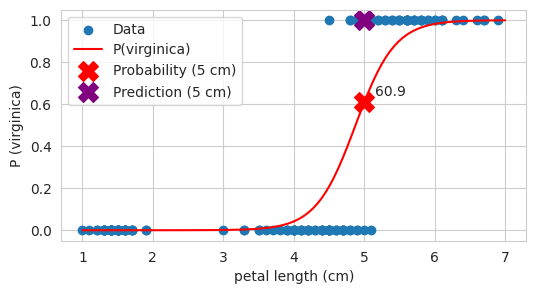

In [ ]:
plt.figure(figsize=(6, 3))
plt.scatter(X_single, y_binary, label="Data")
plt.plot(x_sigmoid, y_sigmoid[:, 1], 'r-', label=f"P({iris.target_names[2]})") # Probability of access

plt.scatter(new_petal_width, prob_virginica, color='red', marker='X', s=200, label="Probability (5 cm)")
plt.scatter(new_petal_width, prediction, color='purple', marker='X', s=200, label="Prediction (5 cm)")

plt.annotate(round(prob_virginica,3)*100, (new_petal_width, prob_virginica), xytext=(8, 5), textcoords='offset points')

plt.xlabel(iris.feature_names[2])
plt.ylabel(f"P ({iris.target_names[2]})")
plt.legend()
plt.grid(True)
plt.show()

## Part 2: Complete Multiclass Classification Pipeline

Now we proceed to the real-world workflow using **all 4 features** to classify **all 3 species**. This demonstrates professional ML practices.

### The Complete ML Workflow

Every classification project follows these essential steps:

1. **Split data**: Separate training and testing sets (prevent data leakage)
2. **Scale features**: Standardize for better performance
3. **Train model**: Fit the algorithm to training data
4. **Evaluate model**: Assess performance on test data
5. **Analyze results**: Understand predictions and errors

### Why This Order Matters

⚠️ **Critical**: Split FIRST, then scale. Otherwise you leak information from test set into training!

In [ ]:
# Step 1: Split Data (70% train, 30% test)
# stratify=y_all ensures balanced class distribution in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, 
    test_size=0.3,        # 30% for testing
    random_state=42,      # For reproducibility
    stratify=y_all        # Maintain class proportions
)

print("Step 1: Data Split")
print("=" * 60)
print(f"Total samples:      {len(X_all):3d}")
print(f"Training samples:   {len(X_train):3d} ({len(X_train)/len(X_all)*100:.1f}%)")
print(f"Test samples:       {len(X_test):3d} ({len(X_test)/len(X_all)*100:.1f}%)")
print(f"\nTraining shape: {X_train.shape}")
print(f"Test shape:     {X_test.shape}")

# Verify stratification
print("\nClass distribution verification:")
for i, species in enumerate(iris.target_names):
    train_count = np.sum(y_train == i)
    test_count = np.sum(y_test == i)
    train_pct = train_count / len(y_train) * 100
    test_pct = test_count / len(y_test) * 100
    print(f"  {species:12s}: Train {train_count:2d} ({train_pct:.1f}%)  |  Test {test_count:2d} ({test_pct:.1f}%)")

print("\n✓ Stratification successful - balanced splits!")

Step 1: Data Split
Total samples:      150
Training samples:   105 (70.0%)
Test samples:        45 (30.0%)

Training shape: (105, 4)
Test shape:     (45, 4)

Class distribution verification:
  setosa      : Train 35 (33.3%)  |  Test 15 (33.3%)
  versicolor  : Train 35 (33.3%)  |  Test 15 (33.3%)
  virginica   : Train 35 (33.3%)  |  Test 15 (33.3%)

✓ Stratification successful - balanced splits!


In [ ]:
# Step 2: Feature Scaling (Standardization)
# Formula: z = (x - μ) / σ  where μ=mean, σ=std
scaler = StandardScaler()

# IMPORTANT: Fit scaler only on training data!
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)

# Transform test data using training statistics
X_test_scaled = scaler.transform(X_test)  # NOT fit_transform!

print("Step 2: Feature Scaling")
print("=" * 60)
print("Learned statistics from training data:")
for i, feature in enumerate(iris.feature_names):
    print(f"  {feature:25s}: mean={scaler.mean_[i]:6.3f}, std={scaler.scale_[i]:6.3f}")

print(f"\nTraining data after scaling:")
print(f"  Mean per feature: {X_train_scaled.mean(axis=0)}")
print(f"  Std per feature:  {X_train_scaled.std(axis=0)}")

print(f"\n⚠ Critical: Test data scaled using training statistics!")
print(f"   This prevents data leakage.")

Step 2: Feature Scaling
Learned statistics from training data:
  sepal length (cm)        : mean= 5.873, std= 0.859
  sepal width (cm)         : mean= 3.055, std= 0.455
  petal length (cm)        : mean= 3.785, std= 1.776
  petal width (cm)         : mean= 1.206, std= 0.774

Training data after scaling:
  Mean per feature: [ 2.38327876e-15 -1.12145742e-15 -1.37456184e-16 -6.97854473e-17]
  Std per feature:  [1. 1. 1. 1.]

⚠ Critical: Test data scaled using training statistics!
   This prevents data leakage.


In [ ]:
# Step 3: Train Model
# Scikit-learn handles multiclass automatically (using One-vs-Rest or Multinomial)
log_reg_multi = LogisticRegression(random_state=42, max_iter=1000)
log_reg_multi.fit(X_train_scaled, y_train)

print("Step 3: Model Training")
print("=" * 60)
print("✓ Logistic Regression model trained successfully!")
print(f"\nModel trained on {len(X_train)} samples")
print(f"Number of classes: {len(log_reg_multi.classes_)}")
print(f"Classes: {iris.target_names[log_reg_multi.classes_].tolist()}")

print("\nModel coefficients (feature importance):")
coef_df = pd.DataFrame(
    log_reg_multi.coef_,
    index=iris.target_names,
    columns=iris.feature_names
)
print(coef_df.round(3))

Step 3: Model Training
✓ Logistic Regression model trained successfully!

Model trained on 105 samples
Number of classes: 3
Classes: ['setosa', 'versicolor', 'virginica']

Model coefficients (feature importance):
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
setosa                 -1.077             0.955             -1.700   
versicolor              0.473            -0.447             -0.116   
virginica               0.604            -0.507              1.816   

            petal width (cm)  
setosa                -1.603  
versicolor            -0.793  
virginica              2.396  


### Step 4: Model Evaluation

We evaluate the model on the **unseen test set**. This simulates real-world performance.

#### Understanding Classification Metrics

1. **Accuracy**: Overall correct predictions / Total predictions
   - Good for balanced datasets
   - Can be misleading with imbalanced classes

2. **Precision**: Of predicted positives, how many are correct?
   - Formula: $\frac{TP}{TP + FP}$
   - "When I predict class X, how often am I right?"

3. **Recall** (Sensitivity): Of actual positives, how many did we catch?
   - Formula: $\frac{TP}{TP + FN}$
   - "Of all class X samples, how many did I find?"

4. **F1-Score**: Harmonic mean of precision and recall
   - Formula: $2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$
   - Balances both metrics

In [ ]:
# Make predictions
y_train_pred = log_reg_multi.predict(X_train_scaled)
y_test_pred = log_reg_multi.predict(X_test_scaled)

# Calculate metrics
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, average='weighted')
recall = recall_score(y_test, y_test_pred, average='weighted')
f1 = f1_score(y_test, y_test_pred, average='weighted')

print("Step 4: Model Evaluation")
print("=" * 70)
print(f"{'Metric':<20s} {'Training':<15s} {'Test':<15s}")
print("-" * 70)
print(f"{'Accuracy':<20s} {train_acc:<15.4f} {test_acc:<15.4f}")
print(f"{'Precision':<20s} {'':<15s} {precision:<15.4f}")
print(f"{'Recall':<20s} {'':<15s} {recall:<15.4f}")
print(f"{'F1-Score':<20s} {'':<15s} {f1:<15.4f}")
print("=" * 70)

print(f"\nInterpretation:")
print(f"  • The model correctly classifies {test_acc*100:.1f}% of test samples")
print(f"  • Training accuracy: {train_acc*100:.1f}%")
print(f"  • Gap: {(train_acc - test_acc)*100:.2f}% (small gap = good generalization)")

# Check for overfitting
acc_gap = train_acc - test_acc
if acc_gap < 0.02:
    print("\n✓ Excellent! No overfitting detected.")
elif acc_gap < 0.05:
    print("\n✓ Good! Minimal overfitting.")
else:
    print("\n⚠ Some overfitting detected.")

Step 4: Model Evaluation
Metric               Training        Test           
----------------------------------------------------------------------
Accuracy             0.9810          0.9111         
Precision                            0.9155         
Recall                               0.9111         
F1-Score                             0.9107         

Interpretation:
  • The model correctly classifies 91.1% of test samples
  • Training accuracy: 98.1%
  • Gap: 6.98% (small gap = good generalization)

⚠ Some overfitting detected.


### Detailed Classification Report

The classification report shows precision, recall, and F1-score for each class individually.

In [ ]:
print("\nDetailed Classification Report:")
print("=" * 70)
print(classification_report(y_test, y_test_pred, target_names=iris.target_names))

print("Understanding the report:")
print("  • precision: Of predictions for this class, % that were correct")
print("  • recall: Of actual samples of this class, % we found")
print("  • f1-score: Harmonic mean of precision and recall")
print("  • support: Number of actual samples in test set")


Detailed Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45

Understanding the report:
  • precision: Of predictions for this class, % that were correct
  • recall: Of actual samples of this class, % we found
  • f1-score: Harmonic mean of precision and recall
  • support: Number of actual samples in test set


### Step 5: Confusion Matrix Analysis

The **Confusion Matrix** shows us exactly where the model made errors:
- **Rows**: Actual classes
- **Columns**: Predicted classes
- **Diagonal**: Correct predictions
- **Off-diagonal**: Misclassifications

For example: Cell [Versicolor, Virginica] = 2 means "2 Versicolor samples were misclassified as Virginica"

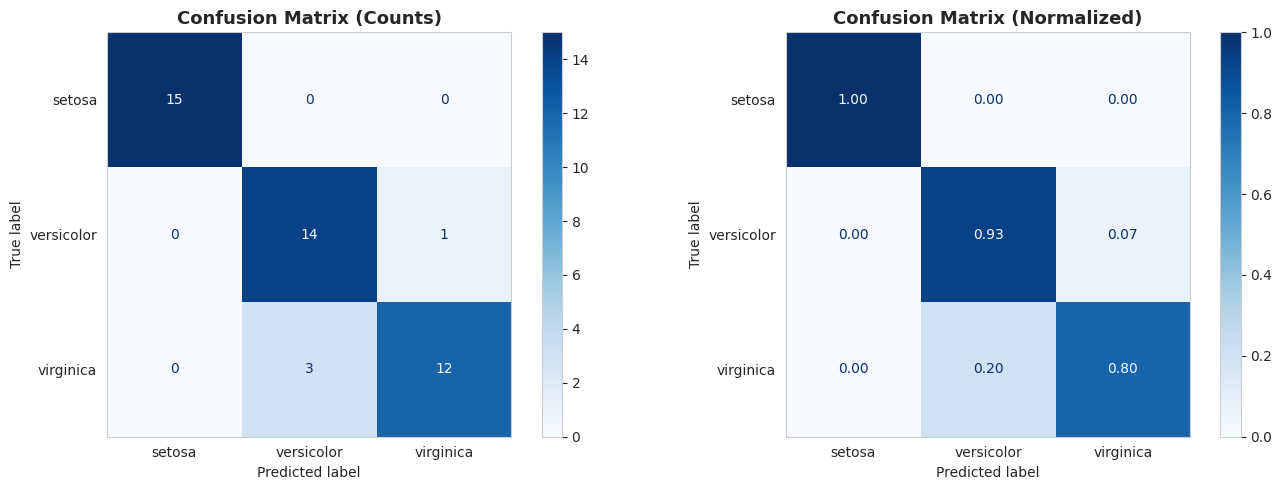


Detailed Confusion Matrix Analysis:

SETOSA:
  Correctly classified: 15/15 (100.0%)
  ✓ Perfect classification!

VERSICOLOR:
  Correctly classified: 14/15 (93.3%)
  Misclassified as:
    - virginica: 1 sample(s)

VIRGINICA:
  Correctly classified: 12/15 (80.0%)
  Misclassified as:
    - versicolor: 3 sample(s)

Typical pattern:
  • Setosa is usually perfectly separated (no confusion)
  • Versicolor and Virginica occasionally confused
  • This matches what we saw in the exploratory analysis!


In [ ]:
conf_mat = confusion_matrix(y_test, y_test_pred)

# Create side-by-side visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Count matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels=iris.target_names)
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0].grid(False)

# Right: Normalized matrix (shows percentages)
cm_norm = conf_mat.astype('float') / conf_mat.sum(axis=1)[:, np.newaxis]
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=iris.target_names)
disp_norm.plot(ax=axes[1], cmap='Blues', values_format='.2f')
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')
axes[1].grid(False)

plt.tight_layout()
plt.show()

# Detailed analysis
print("\nDetailed Confusion Matrix Analysis:")
print("=" * 70)

for i, class_name in enumerate(iris.target_names):
    correct = conf_mat[i, i]
    total = conf_mat[i, :].sum()
    
    print(f"\n{class_name.upper()}:")
    print(f"  Correctly classified: {correct}/{total} ({correct/total*100:.1f}%)")
    
    # Show misclassifications
    errors = [(j, conf_mat[i, j]) for j in range(len(iris.target_names)) if i != j and conf_mat[i, j] > 0]
    if errors:
        print(f"  Misclassified as:")
        for j, count in errors:
            print(f"    - {iris.target_names[j]}: {count} sample(s)")
    else:
        print(f"  ✓ Perfect classification!")

print("\nTypical pattern:")
print("  • Setosa is usually perfectly separated (no confusion)")
print("  • Versicolor and Virginica occasionally confused")
print("  • This matches what we saw in the exploratory analysis!")

### Probability Predictions

One advantage of Logistic Regression is that it provides **confidence scores** (probabilities) for predictions.

In [ ]:
# Get probability predictions for test set
y_test_proba = log_reg_multi.predict_proba(X_test_scaled)

print("Sample probability predictions (first 10 test samples):")
print("=" * 80)

proba_df = pd.DataFrame(
    y_test_proba[:10],
    columns=iris.target_names
)
proba_df['Actual'] = [iris.target_names[y] for y in y_test[:10]]
proba_df['Predicted'] = [iris.target_names[y] for y in y_test_pred[:10]]
proba_df['Correct?'] = ['✓' if y_test[i] == y_test_pred[i] else '✗' for i in range(10)]

print(proba_df.to_string(index=False))

print("\nInterpretation:")
print("  • Each row sums to 1.0 (100% probability)")
print("  • Higher probability = more confident prediction")
print("  • Useful for identifying uncertain predictions")
print("  • Can set custom thresholds for high-stakes decisions")

Sample probability predictions (first 10 test samples):
  setosa  versicolor  virginica     Actual  Predicted Correct?
0.000033    0.101448   0.898519  virginica  virginica        ✓
0.014118    0.789437   0.196445 versicolor versicolor        ✓
0.003581    0.620192   0.376226  virginica versicolor        ✗
0.021810    0.629198   0.348991 versicolor versicolor        ✓
0.005152    0.384551   0.610297  virginica  virginica        ✓
0.000040    0.022438   0.977522  virginica  virginica        ✓
0.015777    0.914670   0.069553 versicolor versicolor        ✓
0.033727    0.938517   0.027756 versicolor versicolor        ✓
0.937675    0.062321   0.000004     setosa     setosa        ✓
0.000117    0.054758   0.945125  virginica  virginica        ✓

Interpretation:
  • Each row sums to 1.0 (100% probability)
  • Higher probability = more confident prediction
  • Useful for identifying uncertain predictions
  • Can set custom thresholds for high-stakes decisions


## Summary and Key Takeaways

### What We Learned

1. **Building Intuition First**: Started with single-variable classification to visualize the sigmoid curve
2. **The Complete ML Workflow**: Load → Split → Scale → Train → Evaluate → Analyze
3. **Proper Data Handling**: 
   - Always split before scaling
   - Use stratification for balanced splits
   - Prevent data leakage (fit scaler only on training data)
4. **Comprehensive Evaluation**: Multiple metrics provide different perspectives
5. **Error Analysis**: Confusion matrix reveals which classes are confused

### Logistic Regression: Strengths and Limitations

**Strengths:**
- ✓ Fast and efficient to train
- ✓ Provides probability estimates (not just predictions)
- ✓ Interpretable coefficients show feature importance
- ✓ Works well for linearly separable data
- ✓ Good baseline model (try this first!)
- ✓ No hyperparameters to tune (simple)

**Limitations:**
- ✗ Assumes linear decision boundaries
- ✗ Can't capture complex non-linear patterns
- ✗ Sensitive to feature scaling
- ✗ May underfit complex datasets

### When to Use Logistic Regression

**Use Logistic Regression when:**
- You need a fast, interpretable baseline
- Classes are linearly separable (or nearly so)
- You need probability estimates
- Interpretability is important (e.g., medical, legal applications)
- You want to understand feature importance

**Consider other algorithms when:**
- Decision boundaries are highly non-linear
- Feature interactions are complex
- You need the absolute best performance regardless of interpretability

### Best Practices Checklist

✓ **Always split data first** (before any preprocessing)  
✓ **Use stratification** for balanced splits  
✓ **Fit scaler/preprocessor only on training data**  
✓ **Use same preprocessing for train and test**  
✓ **Evaluate with multiple metrics** (not just accuracy)  
✓ **Check confusion matrix** for error patterns  
✓ **Verify no overfitting** (compare train vs test)  
✓ **Examine probability predictions** for confidence  
✓ **Set random_state** for reproducibility  
✓ **Document your process** clearly  

### What's Next?

This notebook taught the fundamental classification workflow with Logistic Regression. Future topics:

1. **Pipelines**: Automate preprocessing + training in one object
2. **Cross-Validation**: More robust evaluation than single train/test split
3. **Multiple Algorithms**: Compare with KNN, Decision Trees, Random Forests, SVMs
4. **Hyperparameter Tuning**: Optimize model parameters
5. **Feature Engineering**: Create new features to improve performance
6. **Handling Imbalanced Data**: Techniques for skewed class distributions